In [ ]:
from pathlib import Path
import os

import jax
import jax.numpy as jnp
import numpy as np
import equinox as eqx

from llm_equilibrium_core import (
    TripletModel,
    Dataset,
    TrainConfig,
    train,
    get_FIM
)

jax.config.update("jax_enable_x64", True)

test = """# Load CSVs into datasets
input_dir = "data"
output_dir = "output"

output_dir = Path(output_dir)
output_dir.mkdir(parents=True, exist_ok=True)


for file in os.listdir("data"):
    dataset = Dataset.from_csv(f"{input_dir}/{file}")
    dataset.to_npz(output_dir / f"{file.split('.')[0]}.npz")"""

E0427 00:02:28.240880  444545 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
E0427 00:02:28.250779  444413 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)


In [2]:
class MLP_DER(TripletModel):
    line1: eqx.nn.Linear
    line2: eqx.nn.Linear

    def __init__(self, key: jax.Array):
        in_size = 3
        width = 16
        out_size = 1

        k1, k2 = jax.random.split(key, 2)

        self.line1 = eqx.nn.Linear(in_size, width, key=k1)
        self.line2 = eqx.nn.Linear(width, out_size, key=k2)

    def __call__(self, del_strain: jax.Array) -> jax.Array:
        x = self.line1(del_strain)
        x = jax.nn.softplus(x)
        x = self.line2(x)
        return jax.nn.softplus(x)[0]


class DER(TripletModel):
    K: jax.Array

    def __init__(self, key: jax.Array):
        self.K = jax.random.normal(key, (3,)) + 1.0

    def __call__(self, del_strain: jax.Array) -> jax.Array:
        return jnp.sum(jnp.abs(self.K) * del_strain**2)


dataset_train = Dataset.from_npz("output/dlo_DLO_brizier_2d_rect_2332pts_a1de640e.npz")
dataset_valid = Dataset.from_npz("output/dlo_DLO_brizier_2d_rect_2332pts_a1de640e.npz")
config = TrainConfig(
    length=dataset_train.length, epochs=5000, lr=1e-2, S_factor=0.0, print_every=500
)
model, train_loss, valid_loss = train(
    MLP_DER, dataset_train, dataset_valid, config=config
)

Starting training for 5000 epochs...
Epoch 0500 | Train Loss: 0.000078 | Valid Loss: 0.000078
Epoch 1000 | Train Loss: 0.000027 | Valid Loss: 0.000027
Epoch 1500 | Train Loss: 0.000012 | Valid Loss: 0.000012
Epoch 2000 | Train Loss: 0.000006 | Valid Loss: 0.000006
Epoch 2500 | Train Loss: 0.000004 | Valid Loss: 0.000004
Epoch 3000 | Train Loss: 0.000002 | Valid Loss: 0.000002
Epoch 3500 | Train Loss: 0.000002 | Valid Loss: 0.000002
Epoch 4000 | Train Loss: 0.000001 | Valid Loss: 0.000001
Epoch 4500 | Train Loss: 0.000001 | Valid Loss: 0.000001
Epoch 5000 | Train Loss: 0.000001 | Valid Loss: 0.000001


### Viz

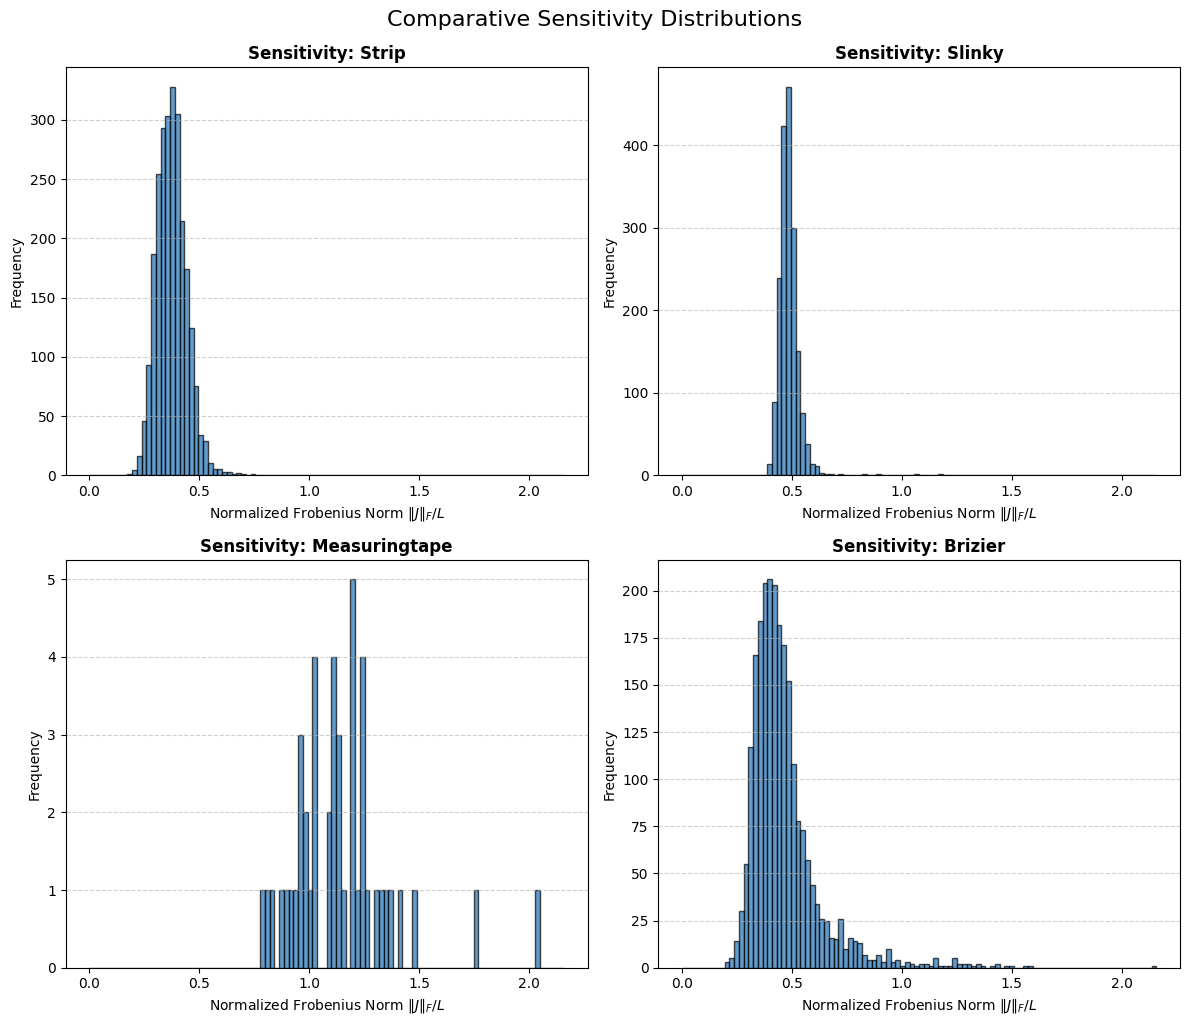

In [3]:
import matplotlib.pyplot as plt


def visualize_sensitivity_batch(
    file_list, output_dir="output", bins=100, fixed_range=True
):
    """
    Loads 4 npz files, calculates Frobenius norms of 'S',
    and plots them in a 2x2 grid.
    """
    if len(file_list) != 4:
        print(f"Expected 4 files, got {len(file_list)}. Adjusting grid...")

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()

    # Optional: Find global max for a shared X-axis to make comparison fair
    global_max = 0
    all_norms = []

    for file in file_list:
        path = os.path.join(output_dir, file)
        data = jnp.load(path)
        # Assuming 'S' is your N x X x Y sensitivity matrix
        S = data["S"]
        norms = jnp.linalg.norm(S, ord="fro", axis=(1, 2)) / data["length"]
        all_norms.append(norms)
        if jnp.max(norms) > global_max:
            global_max = float(jnp.max(norms))

    for i, file in enumerate(file_list):
        ax = axes[i]
        hrange = (0, global_max) if fixed_range else None

        ax.hist(
            all_norms[i],
            bins=bins,
            range=hrange,
            color="#2171b5",
            edgecolor="black",
            alpha=0.7,
        )

        # Clean up the titles (removes the long hashes/extensions for readability)
        clean_title = (
            file.split("_2d_")[0]
            .replace("dlo_", "")
            .replace("_", "")
            .replace("DLO", "")
            .title()
        )
        ax.set_title(f"Sensitivity: {clean_title}", fontsize=12, fontweight="bold")
        ax.set_xlabel(r"Normalized Frobenius Norm $\|J\|_F/L$")
        ax.set_ylabel("Frequency")
        ax.grid(axis="y", linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.suptitle("Comparative Sensitivity Distributions", fontsize=16, y=1.02)
    plt.show()


# Example Usage:
my_files = [
    "dlo_DLO_strip_2d_rect_2512pts_3c604dce.npz",
    "dlo_DLO_slinky_2d_rect_1836pts_036d2b1e.npz",
    "dlo_DLO_measuringtape_2d_11_nodes_sofn3aiwo.npz",
    "dlo_DLO_brizier_2d_rect_2332pts_a1de640e.npz",
]

visualize_sensitivity_batch(my_files)

dlo_DLO_strip_2d_rect_2512pts_3c604dce.npz: T-opt: 4.886664243085568; D_opt: -15.162571150217438; E_opt: 1.1112073308967356e-05


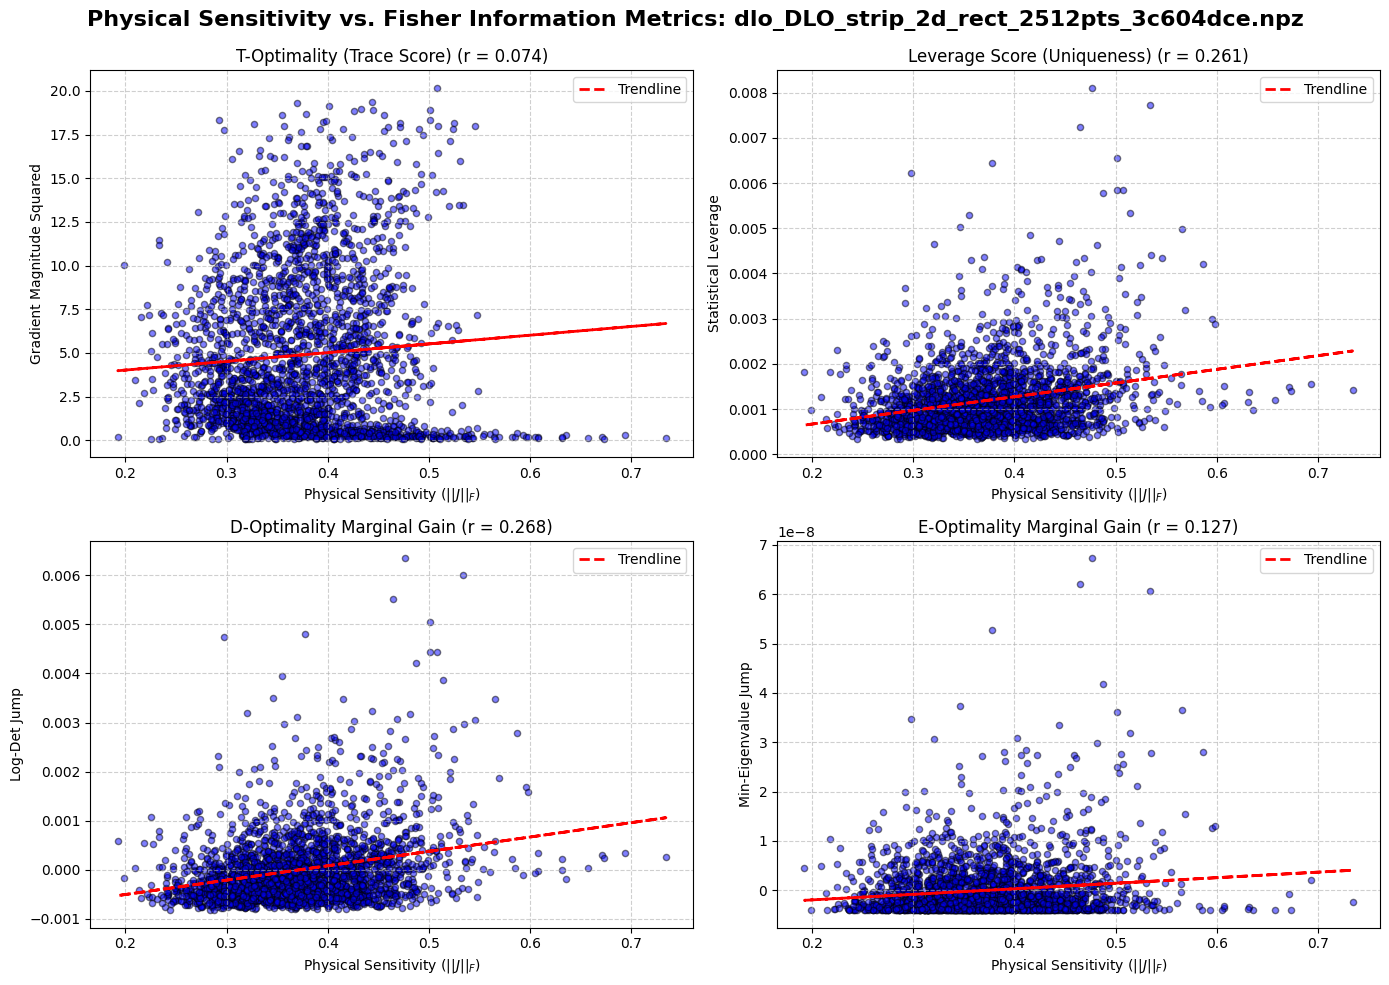

dlo_DLO_slinky_2d_rect_1836pts_036d2b1e.npz: T-opt: 19.033568137087187; D_opt: -1.9941944075484692; E_opt: 0.044013786818140964


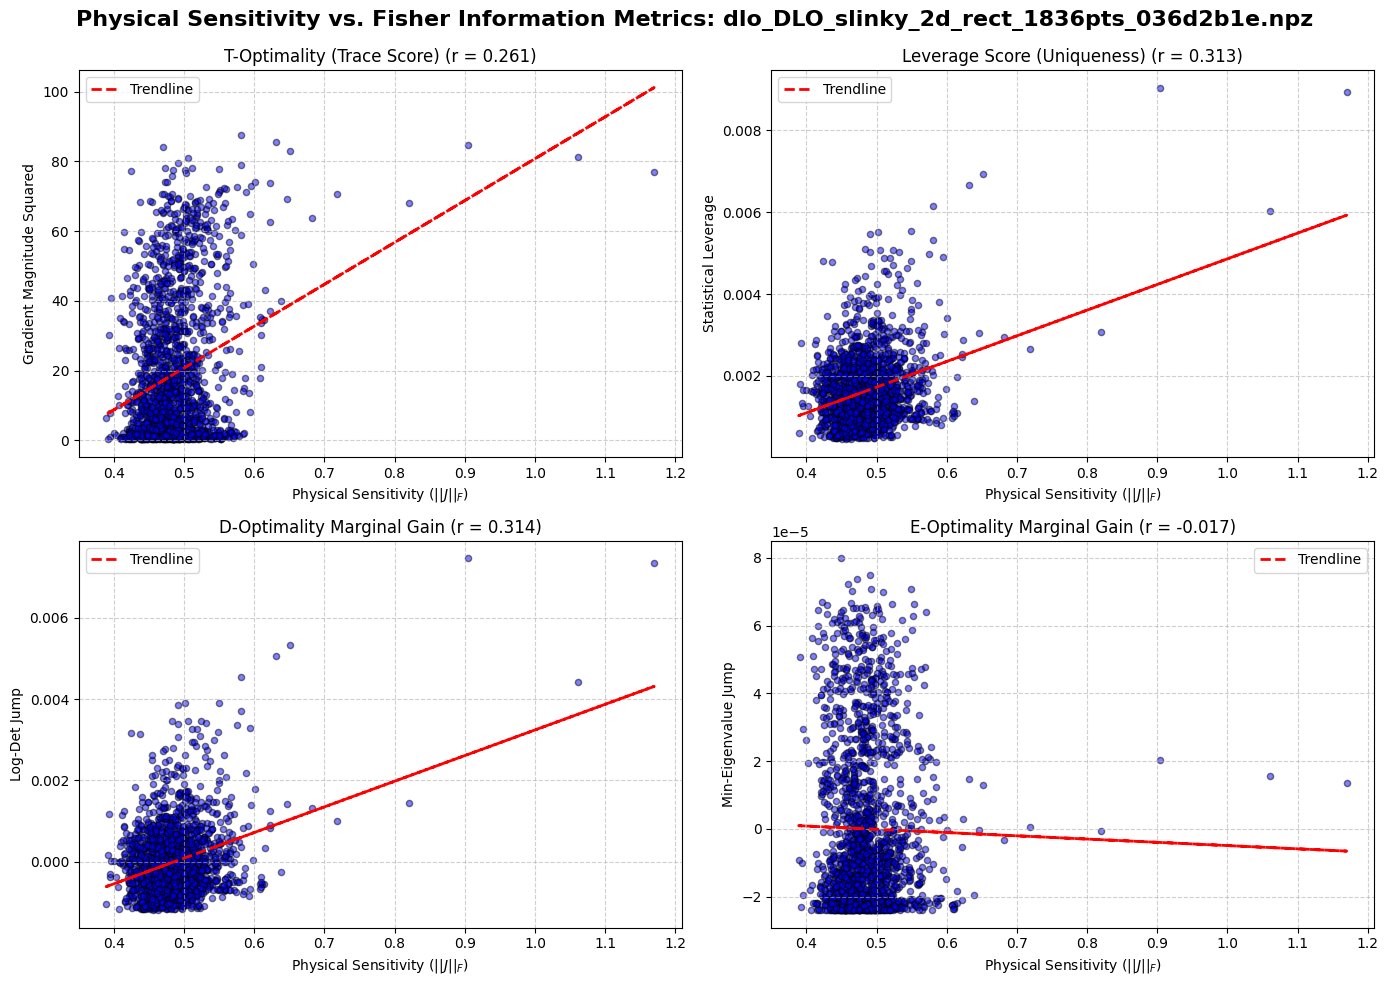

dlo_DLO_measuringtape_2d_11_nodes_sofn3aiwo.npz: T-opt: 4955.240747938526; D_opt: 8.410022513238353; E_opt: 0.0933620457039776


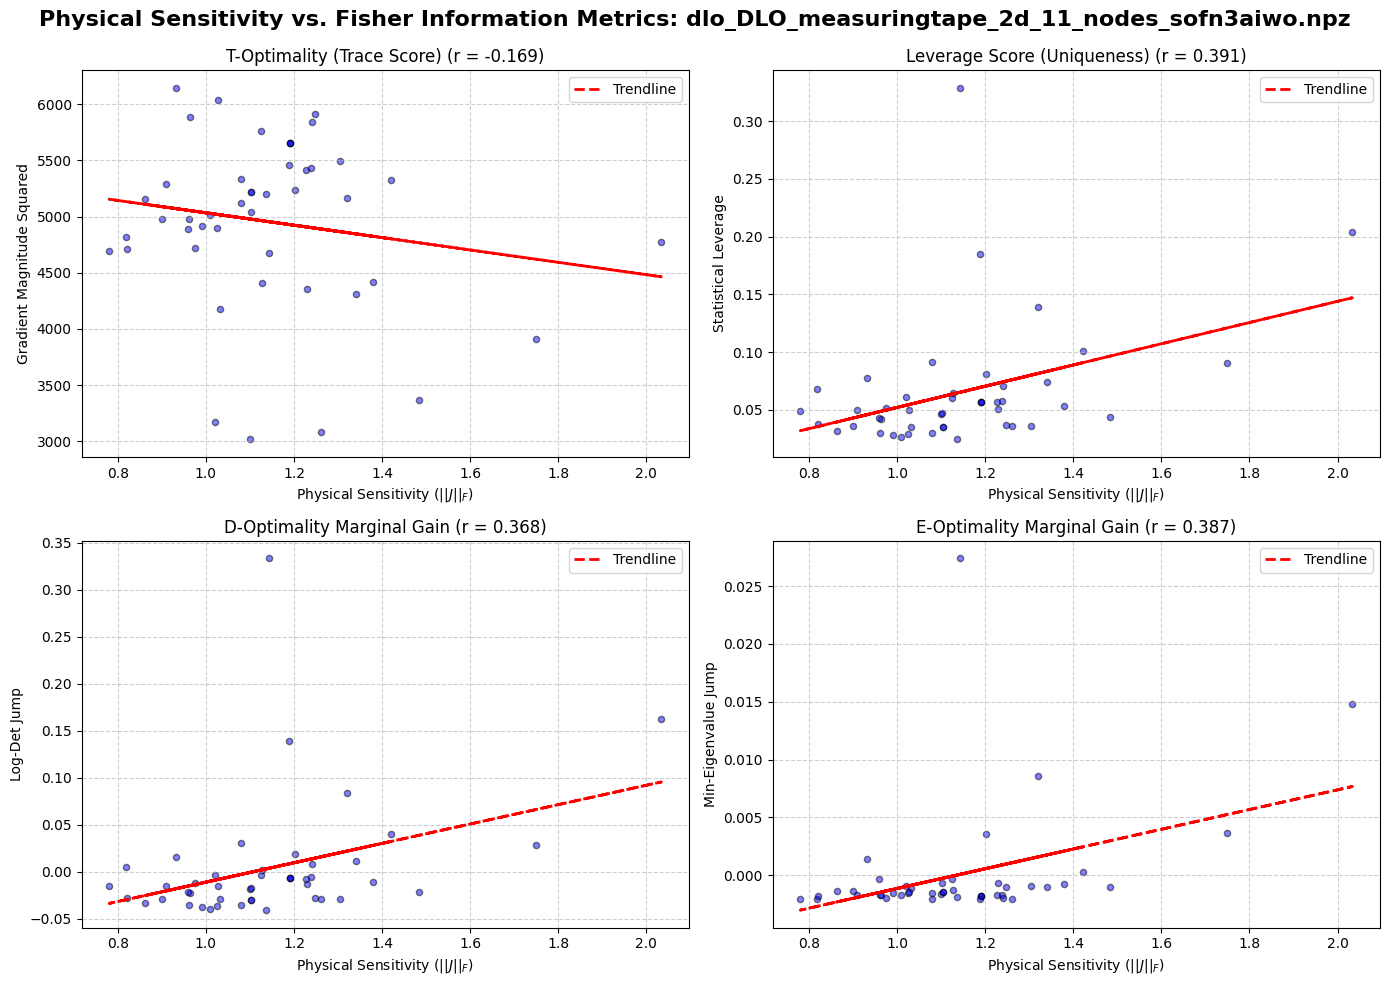

dlo_DLO_brizier_2d_rect_2332pts_a1de640e.npz: T-opt: 7.642620493775016; D_opt: -10.159966278293162; E_opt: 0.0001552791610835908


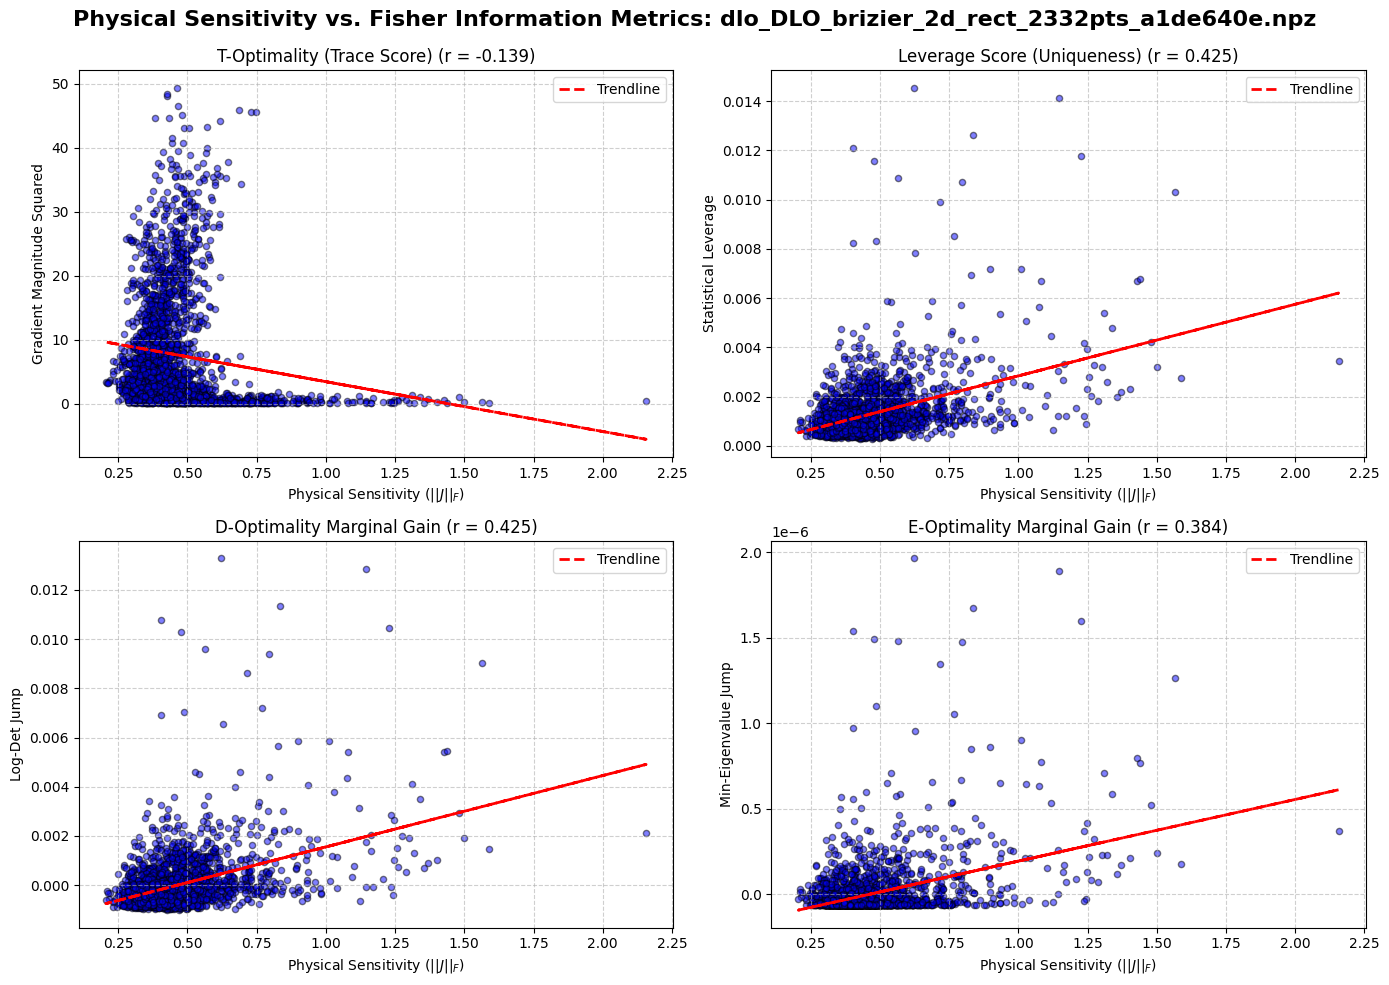

In [5]:
def plot_optimality_correlations(physical_sensitivity, sample_metrics, filepath):
    """
    Creates a 2x2 grid of scatter plots comparing physical sensitivity
    against the 4 independent FIM optimality metrics.

    Args:
        physical_sensitivity: 1D array of your ||J||_F physical norms.
        sample_metrics: Dictionary output from get_FIM.
    """
    # Convert JAX arrays to NumPy arrays for plotting and correlation math
    phys_sens = np.array(physical_sensitivity)
    t_scores = np.array(sample_metrics[0])
    lev_scores = np.array(sample_metrics[1])
    d_gains = np.array(sample_metrics[2])
    e_gains = np.array(sample_metrics[3])

    # Create a 2x2 figure
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(
        f"Physical Sensitivity vs. Fisher Information Metrics: {filepath}",
        fontsize=16,
        fontweight="bold",
        y=0.98,
    )

    # Helper function to plot individual subplots
    def plot_subplot(ax, x, y, title, ylabel):
        ax.scatter(x, y, alpha=0.5, color="b", edgecolor="k", s=20)

        # Calculate correlation coefficient (ignore NaNs/Infs just in case)
        valid = np.isfinite(x) & np.isfinite(y)
        if np.sum(valid) > 1:
            corr = np.corrcoef(x[valid], y[valid])[0, 1]
            ax.set_title(f"{title} (r = {corr:.3f})", fontsize=12)
        else:
            ax.set_title(title, fontsize=12)

        ax.set_xlabel("Physical Sensitivity ($||J||_F$)", fontsize=10)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.grid(True, linestyle="--", alpha=0.6)

        # Add a trendline
        if np.sum(valid) > 1:
            z = np.polyfit(x[valid], y[valid], 1)
            p = np.poly1d(z)
            ax.plot(x[valid], p(x[valid]), "r--", linewidth=2, label="Trendline")
            ax.legend()

    plot_subplot(
        axes[0, 0],
        phys_sens,
        t_scores,
        "T-Optimality (Trace Score)",
        "Gradient Magnitude Squared",
    )
    plot_subplot(
        axes[0, 1],
        phys_sens,
        lev_scores,
        "Leverage Score (Uniqueness)",
        "Statistical Leverage",
    )
    plot_subplot(
        axes[1, 0], phys_sens, d_gains, "D-Optimality Marginal Gain", "Log-Det Jump"
    )
    plot_subplot(
        axes[1, 1],
        phys_sens,
        e_gains,
        "E-Optimality Marginal Gain",
        "Min-Eigenvalue Jump",
    )

    plt.tight_layout()
    fig.subplots_adjust(top=0.92)  # Prevent overlapping titles
    plt.show()


def avg_FIM(
    model_cls: type[TripletModel],
    dataset: Dataset,
    num_models: int = 10,
    config=TrainConfig(),
):
    S_norms = jnp.linalg.norm(dataset.S, ord="fro", axis=(1, 2)) / dataset.length
    root_key = jax.random.PRNGKey(42)
    keys = jax.random.split(root_key, num_models)
    global_metrics, sample_metrics = jax.lax.map(
        lambda key: get_FIM(model_cls(key), dataset, config), keys
    )
    avg_global = jnp.mean(global_metrics, axis=0)
    avg_samples = jnp.mean(sample_metrics, axis=0)
    return S_norms, avg_global, avg_samples


for file in os.listdir("output"):
    dataset = Dataset.from_npz(f"output/{file}")
    if file == "dlo_DLO_measuringtape_2d_11_nodes_sofn3aiwo.npz":
        config = TrainConfig(N=11, length=dataset.length)
    else:
        config = TrainConfig(N=5, length=dataset.length)
    S_norms, avg_globals, avg_samples = avg_FIM(DER, dataset, 10, config=config)
    print(
        f"{file}: T-opt: {avg_globals[0]}; D_opt: {avg_globals[1]}; E_opt: {avg_globals[2]}"
    )
    plot_optimality_correlations(S_norms, avg_samples, file)

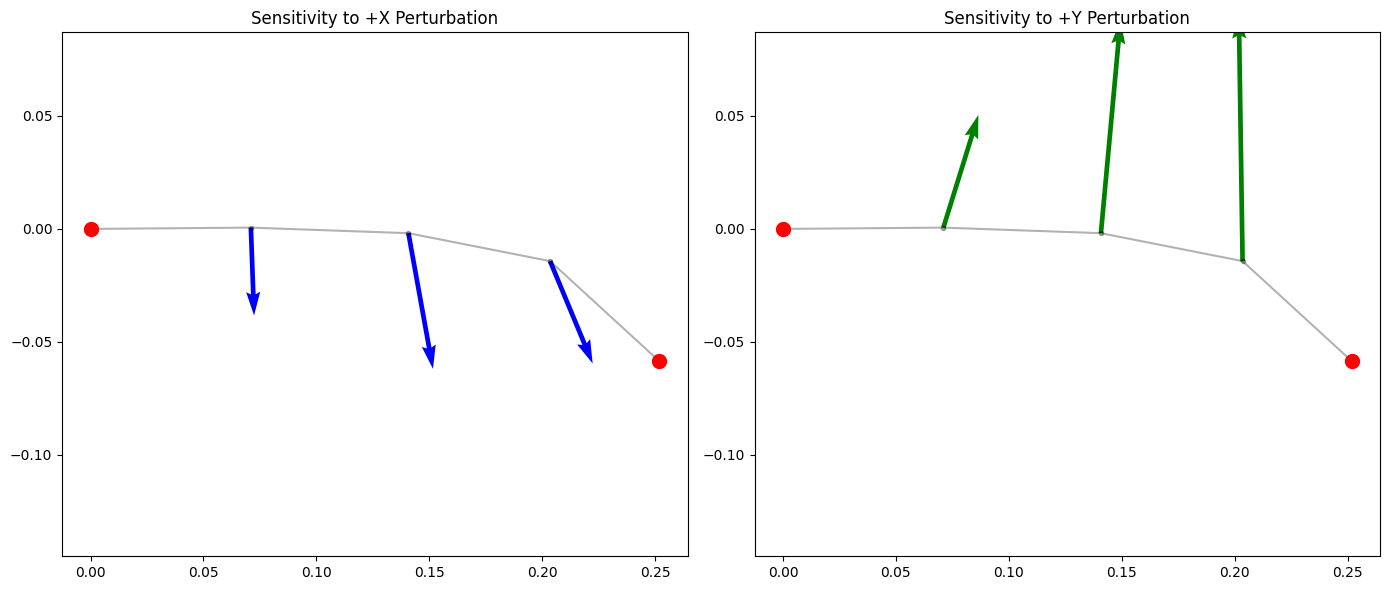

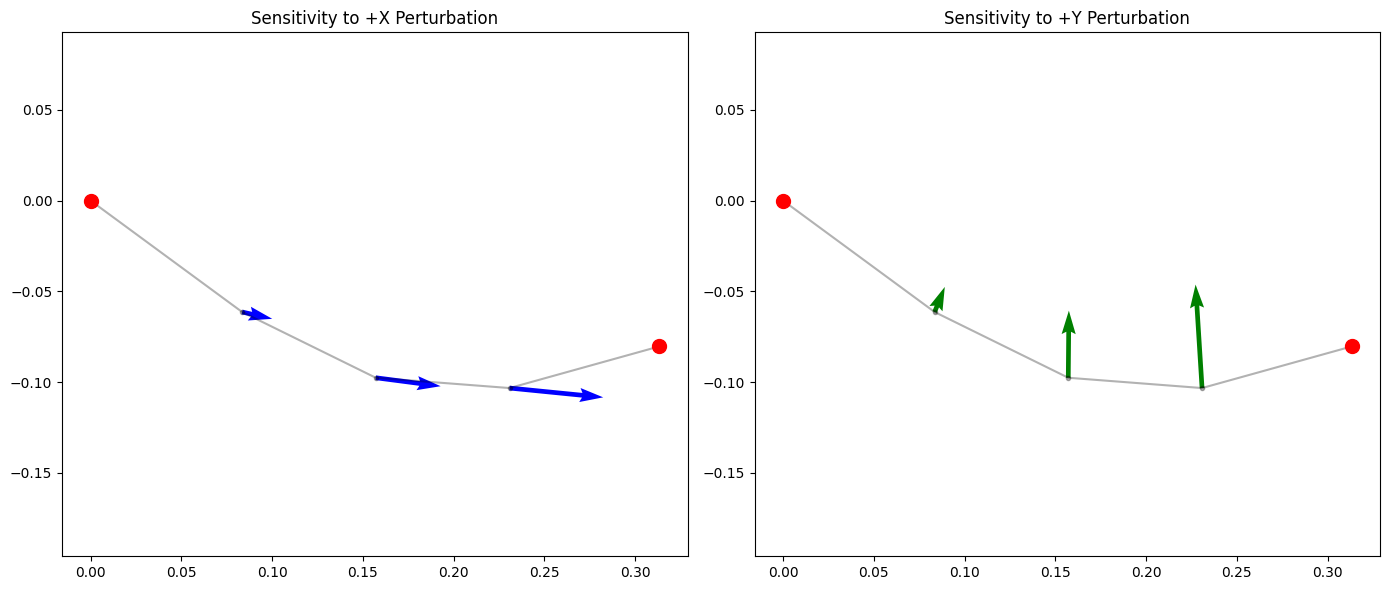

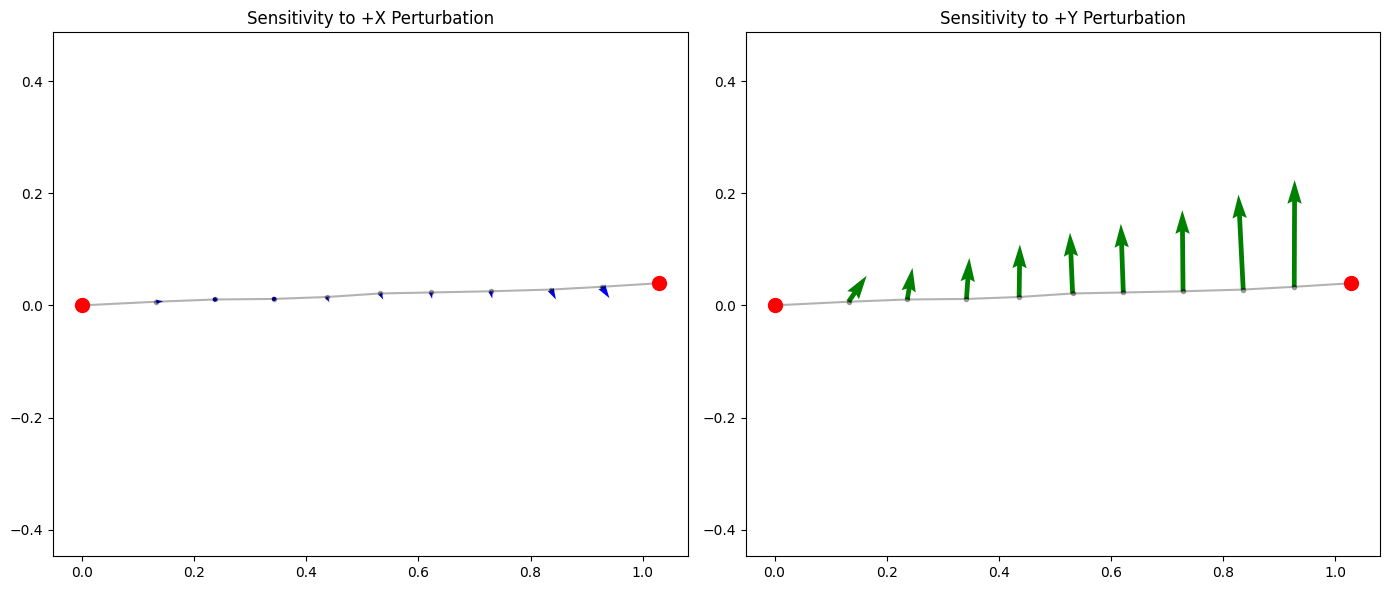

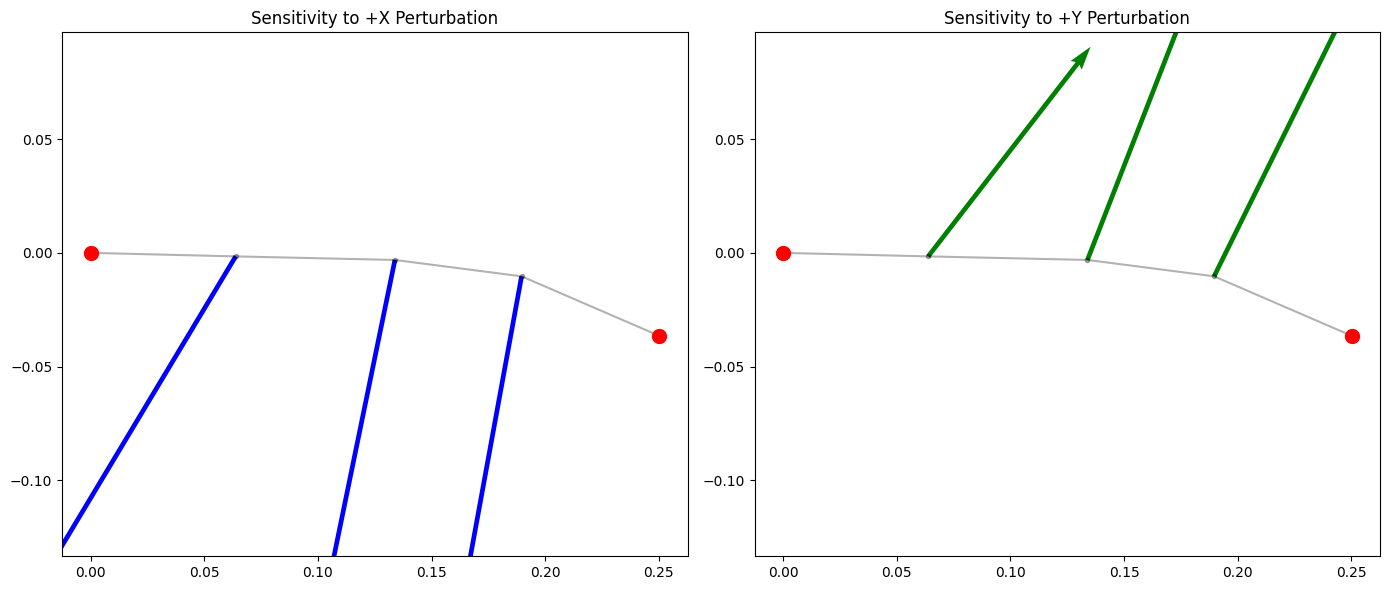

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


def plot_sensitivity_quiver(
    trajectories, S_matrices, state_idx, free_idx, fixed_idx, file=""
):
    # If state_idx is passed as [0], extract the integer
    idx = state_idx[0] if isinstance(state_idx, np.ndarray) else state_idx

    # 1. Extract physical positions
    state_pos = trajectories[idx]
    x_coords = state_pos[:, 0]
    y_coords = state_pos[:, 1]

    # Flatten these to 1D arrays for plotting
    free_x = state_pos[free_idx, 0].flatten()
    free_y = state_pos[free_idx, 1].flatten()

    # 2. Extract Jacobian
    # If S_matrices is (N, 6, 4), S becomes (6, 4)
    S = S_matrices[idx] if len(S_matrices.shape) == 3 else S_matrices

    # Response to the LAST fixed node (the moving boundary)
    # Column -2 is Boundary X, Column -1 is Boundary Y
    response_to_bound_X = S[:, -2]
    response_to_bound_Y = S[:, -1]

    # Map the 6 values in the column to 3 nodes (dx, dy pairs)
    dx_res_X = response_to_bound_X[0::2]
    dy_res_X = response_to_bound_X[1::2]

    dx_res_Y = response_to_bound_Y[0::2]
    dy_res_Y = response_to_bound_Y[1::2]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    plt.title(f"Sensitivty: {file}")
    for ax, dx, dy, title, color in zip(
        [ax1, ax2],
        [dx_res_X, dx_res_Y],
        [dy_res_X, dy_res_Y],
        ["+X Perturbation", "+Y Perturbation"],
        ["blue", "green"],
    ):
        ax.plot(x_coords, y_coords, "k.-", alpha=0.3)
        ax.scatter(x_coords[fixed_idx], y_coords[fixed_idx], c="red", s=100, zorder=5)

        # KEY FIX: The quiver needs 1D arrays of the same length
        ax.quiver(free_x, free_y, dx, dy, color=color, scale=1, scale_units="xy")

        ax.set_title(f"Sensitivity to {title}")
        ax.axis("equal")

    plt.tight_layout()
    plt.show()


for file in os.listdir("output"):
    dataset = Dataset.from_npz(f"output/{file}")
    trajectories = dataset.qs.reshape(dataset.qs.shape[0], -1, 2)
    if file == "dlo_DLO_measuringtape_2d_11_nodes_sofn3aiwo.npz":
        free_idx = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9])
    else:
        free_idx = np.array([1, 2, 3])
    plot_sensitivity_quiver(
        trajectories, dataset.S, 0, free_idx, np.array([0, -1]), file
    )


In [ ]:
test = """qs_total = []

for file in os.listdir("test"):
    data = np.load(f"test/{file}")["qs"]
    data = data.reshape(-1, data.shape[2])
    x, y = data[:, 0::4], data[:, 2::4]
    qs = np.empty((x.shape[0], x.shape[1] + y.shape[1]), dtype=x.dtype)
    qs[:, 0::2] = x
    qs[:, 1::2] = y
    qs_total.append(qs)

qs_total = np.vstack(qs_total)

from llm_equilibrium_core import get_S
trajectories = qs_total.reshape(qs_total.shape[0], -1, 2)
S = get_S(trajectories, base_l2_reg=5e1)
Dataset(qs=jnp.asarray(qs_total), S=jnp.asarray(S), mass=10e-3, length=0.35).to_npz("dlo_DLO_tape_2d_7_nodes_bvr3d1d94.npz")
"""